# AMASS as raw SMPL — the control arm

The same AMASS takes as `preprocess_amass_babel.ipynb`, read from the release `.npz` instead of
the OpenSim CSV, so the feature work the conversion adds can be measured against the data it
started from. The SMPL arm has no anatomical DOFs and no torque: it carries one 6D rotation per
body joint plus its first two frame differences, 21 joints x 18 channels against 43 x 5.

Kept apart from the existing corpus by key, not by directory: `source_dataset="AMASS-SMPL"`,
its own representation name, its own split sets, its own stats file. Nothing already in
`data/processed` is rewritten with a different value — `pretrain_v1`, `babel_official` and every
existing checkpoint's view stay exactly as they are.

Both arms then train on `pretrain_paired_v1`, which holds only the takes **both** imports
produced. The containment runs one way: the conversion ran *from* these `.npz` files, so every
OpenSim take has one behind it, and 1,313 takes exist only on the SMPL side — 451 of LARa's 452,
311 of WEIZMANN's, 105 of CMU's. Left alone, the SMPL arm would train on 8% more corpus and the
difference would read as a feature result.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch as t

from sometria.babel import import_babel_annotations, import_babel_splits
from sometria.catalog import (
    MotionViewSpec,
    build_motion_view,
    create_paired_split,
    load_catalog,
    load_splits,
    normalization_path,
    sample_key,
)
from sometria.normalization import save_feature_normalization
from sometria.preprocess import ImportConfig, import_smpl_dataset
from sometria.representation import build_representation

In [3]:
RAW_AMASS = Path("/home/fziche/nas/MAEVE/dataset/AMASS")
RAW_BABEL = Path("/home/fziche/nas/MAEVE/dataset/babel")
OUT = Path("../data/processed")

ARMS = ("AMASS", "AMASS-SMPL")
PRETRAIN_SPLIT = "pretrain_paired_v1"
BABEL_SPLIT = "babel_paired"
NORMALIZATION_NAME = f"{PRETRAIN_SPLIT}_train_clean"

# a take shorter than the training window is dropped from the view anyway; drop it from the
# pairing too, so the two arms cannot disagree about which takes exist
WINDOW_FRAMES = 240

# each arm's definition file decides its layout, and the layout carries its own name -- so the
# stats path and the catalog column cannot drift from the encoding that produced the tensors
REPRESENTATIONS = {
    "AMASS":      build_representation("../config/human.yaml"),
    "AMASS-SMPL": build_representation("../config/smpl.yaml"),
}
for arm, representation in REPRESENTATIONS.items():
    print(f"{arm:11s} {representation}")

AMASS       Representation('opensim_sincos_log_vel_acc_tau_v2', 43 dofs, 5 channels)
AMASS-SMPL  Representation('smpl_rot6d_log_vel_acc_v1', 21 dofs, 18 channels)


## Import

Glob is `**/*.npz`, not `**/*_stageii.npz`: BMLhandball is an older SMPL-H drop whose 659 takes
are named `<trial>_poses.npz`, and the OpenSim corpus has all of them. Shape-only fits (`_stagei`)
come back through the same glob and are rejected by content — they carry no `poses` array.

The BABEL importers are re-run afterwards because they match on the normalized source path, which
the new rows also carry: the SMPL arm lands on the same official splits as the OpenSim one. They
rewrite the whole splits and annotations tables, with the same values for rows that already existed.

In [3]:
catalog = import_smpl_dataset(
    config=ImportConfig(
        source_dataset="AMASS-SMPL",
        input_root=RAW_AMASS,
        output_root=OUT,
        pattern="**/*.npz",
    ),
    representation=REPRESENTATIONS["AMASS-SMPL"],
)

babel_splits = import_babel_splits(babel_root=RAW_BABEL, output_root=OUT)
babel_annotations = import_babel_annotations(babel_root=RAW_BABEL, output_root=OUT)

print(f"{len(catalog):,} rows in the catalog after the import")
catalog.filter(pl.col("source_dataset") == "AMASS-SMPL").head(3)

100%|██████████| 19256/19256 [42:36<00:00,  7.53it/s] 


skipped 503 unreadable files, e.g. ["/home/fziche/nas/MAEVE/dataset/AMASS/ACCAD/Female1General_c3d/neutral_stagei.npz: ValueError: no 'poses' array (AMASS ships shape-only files too).", "/home/fziche/nas/MAEVE/dataset/AMASS/ACCAD/Female1Gestures_c3d/neutral_stagei.npz: ValueError: no 'poses' array (AMASS ships shape-only files too).", "/home/fziche/nas/MAEVE/dataset/AMASS/ACCAD/Female1Running_c3d/neutral_stagei.npz: ValueError: no 'poses' array (AMASS ships shape-only files too)."]
96,956 rows in the catalog after the import


sample_id,source_dataset,source_subset,source_path,motion_path,representation,metadata,hz,original_hz,n_frames,duration,tau_rate,tau_absmax,nonfinite,broken,n_dofs,n_features
str,str,str,str,str,str,struct[2],f64,f64,i64,f64,f64,f64,bool,bool,i64,i64
"""AMASS-SMPL:LARa/OMoCap_data_ra…","""AMASS-SMPL""","""LARa""","""LARa/OMoCap_data_raw___c3d/Sub…","""motions/amass-smpl/a1e57f13377…","""smpl_rot6d_log_vel_acc_v1""","{null,null}",60.0,200.0,7200,120.0,null,null,false,false,21,18
"""AMASS-SMPL:WEIZMANN/69/Normal_…","""AMASS-SMPL""","""WEIZMANN""","""WEIZMANN/69/Normal_SShapeLR(8)…","""motions/amass-smpl/189baf2b677…","""smpl_rot6d_log_vel_acc_v1""","{null,null}",60.0,100.0,206,3.433333,null,null,false,false,21,18
"""AMASS-SMPL:BMLmovi/Subject_6_F…","""AMASS-SMPL""","""BMLmovi""","""BMLmovi/Subject_6_F_MoSh/Subje…","""motions/amass-smpl/9d58a6134af…","""smpl_rot6d_log_vel_acc_v1""","{null,null}",60.0,120.0,211,3.516667,null,null,false,false,21,18


## Paired splits

`pretrain_v1` already owns the pretraining policy — BABEL train plus everything BABEL never
labelled — so the paired split does not restate it, it intersects it. `exclude_broken` and
`min_frames` are applied here rather than only at view time, because a take dropped from one arm's
view has to leave the other arm too: the broken-torque filter can only ever fire on the OpenSim
arm, since SMPL carries no torque to be discontinuous.

In [4]:
pretrain = create_paired_split(
    output_root=OUT,
    split_set=PRETRAIN_SPLIT,
    source_split_set="pretrain_v1",
    arms=ARMS,
    splits=("train",),
    min_frames=WINDOW_FRAMES,
)

babel_paired = create_paired_split(
    output_root=OUT,
    split_set=BABEL_SPLIT,
    source_split_set="babel_official",
    arms=ARMS,
    splits=("train", "val", "test"),
    min_frames=WINDOW_FRAMES,
)

splits = load_splits(OUT)
print(
    splits
    .filter(pl.col("split_set").is_in([PRETRAIN_SPLIT, BABEL_SPLIT]))
    .with_columns(pl.col("sample_id").str.split(":").list.first().alias("arm"))
    .group_by("split_set", "split", "arm")
    .len()
    .sort("split_set", "split", "arm")
)

shape: (8, 4)
┌────────────────────┬───────┬────────────┬──────┐
│ split_set          ┆ split ┆ arm        ┆ len  │
│ ---                ┆ ---   ┆ ---        ┆ ---  │
│ str                ┆ str   ┆ str        ┆ u32  │
╞════════════════════╪═══════╪════════════╪══════╡
│ babel_paired       ┆ test  ┆ AMASS      ┆ 1452 │
│ babel_paired       ┆ test  ┆ AMASS-SMPL ┆ 1452 │
│ babel_paired       ┆ train ┆ AMASS      ┆ 4661 │
│ babel_paired       ┆ train ┆ AMASS-SMPL ┆ 4661 │
│ babel_paired       ┆ val   ┆ AMASS      ┆ 1560 │
│ babel_paired       ┆ val   ┆ AMASS-SMPL ┆ 1560 │
│ pretrain_paired_v1 ┆ train ┆ AMASS      ┆ 9821 │
│ pretrain_paired_v1 ┆ train ┆ AMASS-SMPL ┆ 9822 │
└────────────────────┴───────┴────────────┴──────┘


## Normalization

The pairing is not symmetric. Every OpenSim take has an `.npz` behind it -- the conversion ran
*from* these files -- so the intersection can only remove takes from the SMPL arm: 1,313 of them,
the ones the conversion dropped (451 of LARa's 452, 311 of WEIZMANN's, 105 of CMU's).

The OpenSim arm should therefore come out of the pairing unchanged, and its existing
`pretrain_v1` statistics and checkpoints stay valid as the baseline. Should, not does: a take
whose SMPL frame count lands just under the window, or whose `.npz` fails to load, takes its
OpenSim twin with it. The cell below compares the two sets rather than assuming either answer.


In [5]:
def pretrain_spec(arm: str) -> MotionViewSpec:
    return MotionViewSpec(
        representation=REPRESENTATIONS[arm].name,
        split_set=PRETRAIN_SPLIT,
        split="train",
        source_datasets=(arm,),
        min_frames=WINDOW_FRAMES,
    )


views = {arm: build_motion_view(OUT, pretrain_spec(arm)) for arm in ARMS}

# what the OpenSim arm trained on before the pairing, under the same filters
previous = build_motion_view(
    OUT,
    MotionViewSpec(
        representation=REPRESENTATIONS["AMASS"].name,
        split_set="pretrain_v1",
        split="train",
        source_datasets=("AMASS",),
        min_frames=WINDOW_FRAMES,
    ),
)
lost = set(previous["sample_id"]) - set(views["AMASS"]["sample_id"])
if lost:
    print(f"pairing cost the OpenSim arm {len(lost)} takes -- retrain it on {PRETRAIN_SPLIT}")
    print(f"  e.g. {sorted(lost)[:3]}")
else:
    print(f"OpenSim arm unchanged by the pairing ({len(previous):,} takes): "
          f"existing pretrain_v1 runs remain valid as the baseline")

for arm, representation in REPRESENTATIONS.items():
    path = save_feature_normalization(
        output_root=OUT,
        samples=views[arm],
        name=NORMALIZATION_NAME,
        representation=representation,
        spec=pretrain_spec(arm),
    )
    hours = views[arm]["duration"].sum() / 3600
    print(f"{arm:11s} {len(views[arm]):>6,} takes  {hours:>7.1f} h  ->  {path}")

OpenSim arm unchanged by the pairing (9,821 takes): existing pretrain_v1 runs remain valid as the baseline


100%|██████████| 9821/9821 [00:04<00:00, 2095.79it/s]


AMASS        9,821 takes     25.8 h  ->  ../data/processed/stats/opensim_sincos_log_vel_acc_tau_v2/pretrain_paired_v1_train_clean.pt


100%|██████████| 9822/9822 [00:12<00:00, 759.10it/s] 

AMASS-SMPL   9,822 takes     30.3 h  ->  ../data/processed/stats/smpl_rot6d_log_vel_acc_v1/pretrain_paired_v1_train_clean.pt


## The two arms hold the same takes

The assertion is the point of the notebook. Take keys are normalized paths, which is what makes
them comparable at all: the OpenSim tree uses BABEL's folder names (`EyesJapanDataset`,
`DFaust67`, `MPIHDM05`), the AMASS release its own (`Eyes_Japan_Dataset`, `DFaust`, `HDM05`).

In [6]:
def takes(samples: pl.DataFrame) -> set[str]:
    return set(
        samples.select(
            pl.col("source_path").map_elements(sample_key, return_dtype=pl.String)
        ).to_series()
    )


opensim_takes, smpl_takes = takes(views["AMASS"]), takes(views["AMASS-SMPL"])
assert opensim_takes == smpl_takes, f"arms disagree on {len(opensim_takes ^ smpl_takes)} takes"

print(f"{len(opensim_takes):,} takes, identical in both arms")
print(
    pl.DataFrame([
        {
            "arm": arm,
            "takes": len(views[arm]),
            "hours": views[arm]["duration"].sum() / 3600,
            "frames": views[arm]["n_frames"].sum(),
            "dofs": views[arm]["n_dofs"][0],
            "channels": views[arm]["n_features"][0],
        }
        for arm in ARMS
    ]).with_columns(pl.col("hours").round(1))
)

9,791 takes, identical in both arms
shape: (2, 6)
┌────────────┬───────┬───────┬─────────┬──────┬──────────┐
│ arm        ┆ takes ┆ hours ┆ frames  ┆ dofs ┆ channels │
│ ---        ┆ ---   ┆ ---   ┆ ---     ┆ ---  ┆ ---      │
│ str        ┆ i64   ┆ f64   ┆ i64     ┆ i64  ┆ i64      │
╞════════════╪═══════╪═══════╪═════════╪══════╪══════════╡
│ AMASS      ┆ 9821  ┆ 25.8  ┆ 5565962 ┆ 43   ┆ 5        │
│ AMASS-SMPL ┆ 9822  ┆ 30.3  ┆ 6538642 ┆ 21   ┆ 18       │
└────────────┴───────┴───────┴─────────┴──────┴──────────┘


## What the pairing cost

Per subset, the takes each arm imported and how many survived the intersection. A subset where one
arm is far behind the other is where the conversion pipeline lost data, and it is worth knowing
which ones the comparison ends up resting on.

shape: (26, 4)
┌───────────┬───────┬────────────┬────────┐
│ subset    ┆ AMASS ┆ AMASS-SMPL ┆ paired │
│ ---       ┆ ---   ┆ ---        ┆ ---    │
│ str       ┆ u32   ┆ u32        ┆ u32    │
╞═══════════╪═══════╪════════════╪════════╡
│ KIT       ┆ 4147  ┆ 4231       ┆ 2662   │
│ GRAB      ┆ 1338  ┆ 1340       ┆ 1331   │
│ BMLrub    ┆ 2992  ┆ 3061       ┆ 1246   │
│ WEIZMANN  ┆ 1911  ┆ 2222       ┆ 910    │
│ BMLmovi   ┆ 1858  ┆ 1863       ┆ 840    │
│ …         ┆ …     ┆ …          ┆ …      │
│ PosePrior ┆ 27    ┆ 35         ┆ 14     │
│ HumanEva  ┆ 28    ┆ 28         ┆ 13     │
│ DFaust    ┆ 129   ┆ 129        ┆ 11     │
│ LARa      ┆ 1     ┆ 452        ┆ 1      │
│ SSM       ┆ 30    ┆ 30         ┆ 0      │
└───────────┴───────┴────────────┴────────┘


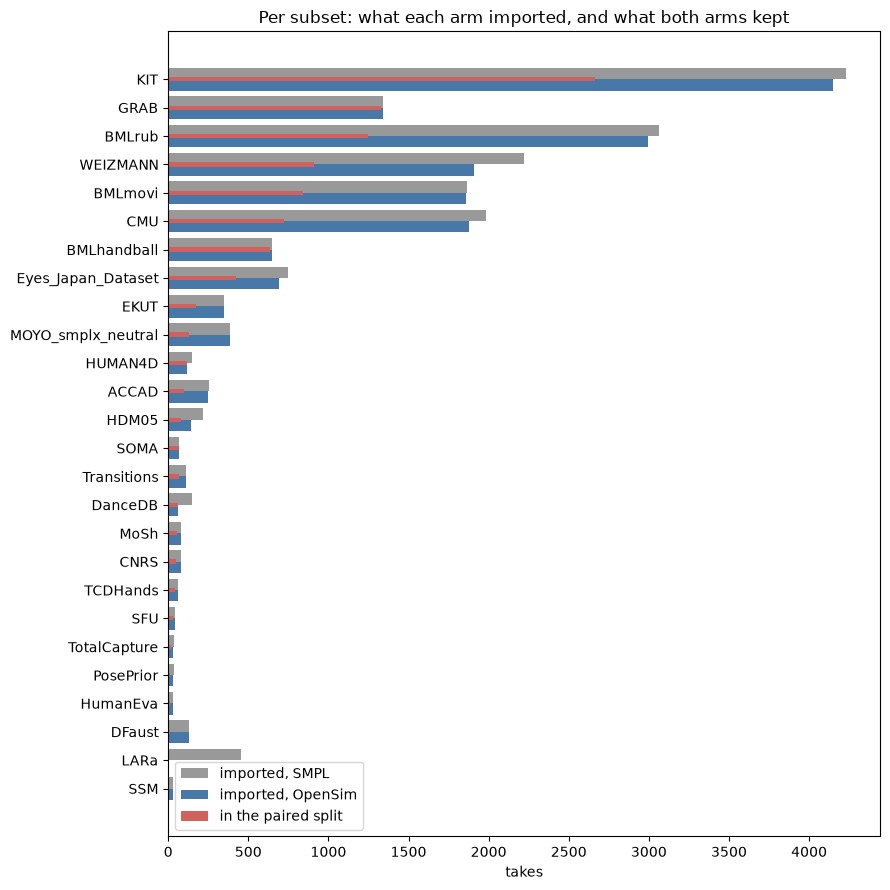

In [7]:
full = load_catalog(OUT).filter(pl.col("source_dataset").is_in(ARMS)).with_columns(
    pl.col("source_path").map_elements(sample_key, return_dtype=pl.String).alias("take"),
).with_columns(pl.col("take").str.split("/").list.first().alias("subset"))

per_subset = (
    full.group_by("subset", "source_dataset").len()
    .pivot(on="source_dataset", index="subset", values="len")
    .fill_null(0)
    .join(
        full.filter(pl.col("take").is_in(list(opensim_takes)))
        .group_by("subset").agg(pl.col("take").n_unique().alias("paired")),
        on="subset", how="left",
    )
    .fill_null(0)
    .sort("paired", descending=True)
)
print(per_subset)

top = per_subset.head(26).sort("paired")
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(y + 0.2, top["AMASS-SMPL"], height=0.4, color="#999999", label="imported, SMPL")
ax.barh(y - 0.2, top["AMASS"], height=0.4, color="#4878a8", label="imported, OpenSim")
ax.barh(y, top["paired"], height=0.15, color="#d1615d", label="in the paired split")
ax.set_yticks(y, top["subset"])
ax.set(xlabel="takes", title="Per subset: what each arm imported, and what both arms kept")
ax.legend()
fig.tight_layout()

## SMPL features

Two things worth seeing before training on them. The pose channels are rotation matrix entries, so
they are bounded and left unnormalized; the derivative channels are frame differences through
signed-log, and those are what the statistics act on. And `decode` has to put a real take's
rotations back where they came from — the 6D form is only useful if it is lossless.

normalized channels:    ['vel0', 'vel1', 'vel2', 'vel3', 'vel4', 'vel5', 'acc0', 'acc1', 'acc2', 'acc3', 'acc4', 'acc5']
pass-through channels:  ['rot0', 'rot1', 'rot2', 'rot3', 'rot4', 'rot5']

decode/encode roundtrip on TotalCapture/s3/rom1_stageii.npz: max |delta| on the pose channels = 7.74e-08
pose channels within [-1, 1]: True


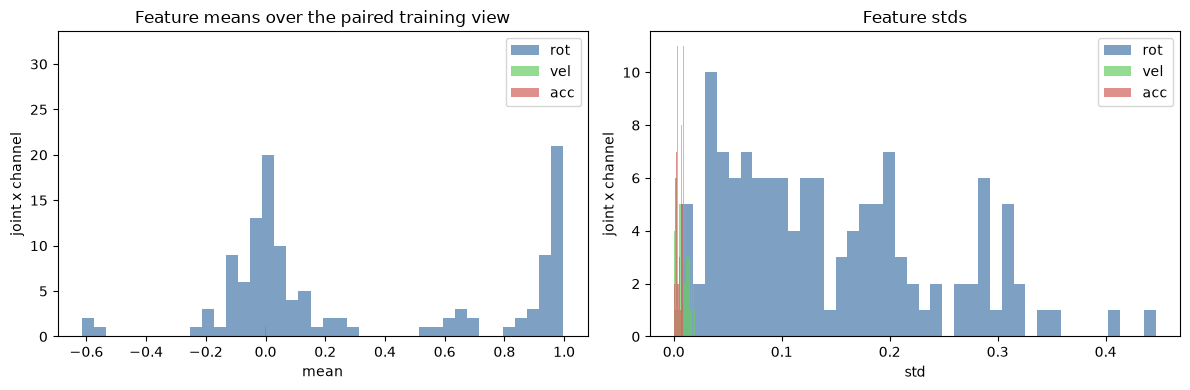

In [8]:
representation = REPRESENTATIONS["AMASS-SMPL"]
stats = t.load(normalization_path(OUT, representation.name, NORMALIZATION_NAME), weights_only=True)
mean, std = stats["mean"].squeeze(0).numpy(), stats["std"].squeeze(0).numpy()

# what the representation normalizes, read off the representation rather than restated here
normalized = np.asarray(representation._mask)[0]
names = list(representation.channels)
print("normalized channels:   ", [n for n, m in zip(names, normalized) if m])
print("pass-through channels: ", [n for n, m in zip(names, normalized) if not m])

example = views["AMASS-SMPL"].sort("duration", descending=True).row(0, named=True)
features = t.load(OUT / example["motion_path"], weights_only=True)["features"].float().numpy()
rotations = representation.decode(features)
reencoded = representation.encode(np.concatenate([np.zeros_like(rotations[:, :1]), rotations], axis=1))
print(f"\ndecode/encode roundtrip on {example['source_path']}: "
      f"max |delta| on the pose channels = {np.abs(reencoded[:, :, :6] - features[:, :, :6]).max():.2e}")
print(f"pose channels within [-1, 1]: {np.abs(features[:, :, :6]).max() <= 1.0}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
groups = [("rot", slice(0, 6), "#4878a8"), ("vel", slice(6, 12), "#6acc64"), ("acc", slice(12, 18), "#d1615d")]

for label, channels, color in groups:
    ax[0].hist(mean[:, channels].reshape(-1), bins=40, alpha=0.7, color=color, label=label)
    ax[1].hist(std[:, channels].reshape(-1), bins=40, alpha=0.7, color=color, label=label)

ax[0].set(title="Feature means over the paired training view", xlabel="mean", ylabel="joint x channel")
ax[1].set(title="Feature stds", xlabel="std", ylabel="joint x channel")
ax[0].legend()
ax[1].legend()
fig.tight_layout()

## Training both arms

```
uv run python train.py --config config/pretrain_mae.yaml config/dataloader/amass_paired.yaml config/mae/medium.yaml --output runs/pretrain/amass_paired/medium_100ep
uv run python train.py --config config/pretrain_mae.yaml config/dataloader/amass_smpl.yaml   config/mae/medium.yaml --output runs/pretrain/amass_smpl/medium_100ep
```

`scripts/pretrain_matrix.sh` cannot drive the SMPL arm: its nine cells override
`channels_input` / `channels_output` with indices into the 5-channel OpenSim layout.